##**Shamini Rajendran**
##**Batch- DA- ML-DA50**


#**<span style="color:blue">DATA ANALYTICS</span>**


**https://www.kaggle.com/datasets/aagneys/end-to-end-sales-analytics?select=End_to_End_Sales_Analytics.csv**



#**Topic-End_to_End_Sales_Analytics**


#***Introduction***
This project focuses on building a Sales Analytics Dashboard using Python to analyze transactional data across multiple dimensions such as customers, products, regions, and sales channels. The dataset contains detailed records of orders, including order dates, customer segments, product categories, revenue, and profit figures.

The goal is to create an end-to-end analytics pipeline that:

Cleans and preprocesses raw sales data.

Performs exploratory data analysis (EDA) to uncover trends.

Builds visualizations for actionable insights.

Provides an overview of business performance across different segments.


#***Project Overview***
#Data Preprocessing

Handle missing values (e.g., missing profit entries).

Standardize inconsistent entries (e.g., “south” vs “South”).

Convert dates into proper datetime format for time-series analysis.

#Exploratory Data Analysis (EDA)

Revenue and profit distribution by product category.

Customer segment contribution to overall sales.

Regional performance comparison.

Impact of discounts on profitability.

#Data Visualization

Bar charts for product category sales.

Heatmaps for regional performance.

Line charts for monthly/quarterly revenue trends.

Scatter plots for discount vs profit correlation.


#Dashboard Creation

Use Matplotlib, Seaborn, and Plotly for interactive charts.



#1. Data Loading and Initial Overview



In [ ]:
#This code is to bring files from  local computer into the Colab environment so we can work with them in Python.

from google.colab import files
uploaded = files.upload()


Saving End_to_End_Sales_Analytics.csv to End_to_End_Sales_Analytics.csv


This code is to load your dataset into Python using Pandas so we can analyze it.

In [ ]:
import pandas as pd

# Load your dataset
df = pd.read_csv("End_to_End_Sales_Analytics.csv")

#Overview

***1. Number of rows and columns - is used to check the dimensions of your dataset.***

***2. Data types of each column - is used to check the data type of every column in your dataset***

***3. Initial observations - is used to get a quick first look at your dataset in Pandas***





In [ ]:


# 1. Number of rows and columns - is used to check the dimensions of your dataset.
print("Shape:", df.shape)

# 2. Data types of each column - is used to check the data type of every column in your dataset
print("\nData Types:\n", df.dtypes)

# 3. Initial observations - is used to get a quick first look at your dataset in Pandas
print("\nHead:\n", df.head())        # First 5 rows
print("\nInfo:\n")
df.info()                            # Column info, non-null counts
print("\nDescribe:\n", df.describe()) # Summary statistics for numeric columns


Shape: (700, 16)

Data Types:
 Order_ID                object
Order_Date              object
Customer_ID             object
Customer_Name           object
Customer_Segment        object
Product_ID              object
Product_Name            object
Product_Category        object
Region                  object
State                   object
Sales_Channel           object
Quantity                 int64
Unit_Price_INR         float64
Discount_Percentage      int64
Revenue_INR            float64
Profit_INR             float64
dtype: object

Head:
    Order_ID  Order_Date Customer_ID   Customer_Name Customer_Segment  \
0  ORD10606  2025-10-25    CUST1291     Rohan Gupta      Home Office   
1  ORD10313  2026-03-11    CUST1330       Meera Das         Consumer   
2  ORD10691  2026-07-11    CUST1215  Divya Krishnan        Corporate   
3  ORD10416  2025-05-10    CUST1114  Divya Krishnan   Small Business   
4  ORD10024  2025-10-05    CUST1171       Meera Das         Consumer   

  Product_ID      

#2.. Data Pre-processing

In [ ]:
# Check missing values
print(df.isnull().sum())



Order_ID                0
Order_Date              0
Customer_ID             0
Customer_Name          19
Customer_Segment        0
Product_ID              0
Product_Name            0
Product_Category        0
Region                  0
State                  15
Sales_Channel          13
Quantity                0
Unit_Price_INR          0
Discount_Percentage     0
Revenue_INR             0
Profit_INR             10
dtype: int64


## Handle Missing Values

Columns  ***Profit_INR , State ,Sales_Channel and Customer_Name have missing entries.***

Handling missing values is one of the most important steps in data cleaning because incomplete data can distort analysis, reduce accuracy, and lead to wrong conclusions. The purpose is to ensure your dataset remains reliable, consistent, and usable.



In [ ]:
df.loc[:, 'Profit_INR'] = df['Profit_INR'].fillna(df['Profit_INR'].median())

In [ ]:
# ✅ Correct handling of missing values in 'State' with explicit observed parameter
df.loc[:, 'State'] = df.groupby('Region', observed=False)['State'].transform(
    lambda x: x.fillna(x.mode()[0] if not x.mode().empty else 'Unknown')
)


In [ ]:
df.loc[:, 'Sales_Channel'] = df['Sales_Channel'].fillna(df['Sales_Channel'].mode()[0])

In [ ]:
# Convert to string dtype first
df['Customer_Name'] = df['Customer_Name'].astype(str)

# Fill missing values safely
df.loc[:, 'Customer_Name'] = df.groupby('Customer_ID')['Customer_Name'].transform(
    lambda x: x.fillna(x.mode()[0] if not x.mode().empty else 'Unknown Customer')
)


In [ ]:
# ✅ Ensure Customer_Name is string type
df['Customer_Name'] = df['Customer_Name'].astype(str)

# Fill missing values by Customer_ID group
df.loc[:, 'Customer_Name'] = df.groupby('Customer_ID')['Customer_Name'].transform(
    lambda x: x.fillna(x.mode()[0] if not x.mode().empty else 'Unknown Customer')
)


In [ ]:
# 1️⃣ Profit_INR → median
df.loc[:, 'Profit_INR'] = df['Profit_INR'].fillna(df['Profit_INR'].median())

# 2️⃣ State → mode within Region
df.loc[:, 'State'] = df.groupby('Region', observed=False)['State'].transform(
    lambda x: x.fillna(x.mode()[0] if not x.mode().empty else 'Unknown')
)

# 3️⃣ Sales_Channel → global mode
df.loc[:, 'Sales_Channel'] = df['Sales_Channel'].fillna(df['Sales_Channel'].mode()[0])

# 4️⃣ Customer_Name → convert to string + infer from Customer_ID
df['Customer_Name'] = df['Customer_Name'].astype(str)
df.loc[:, 'Customer_Name'] = df.groupby('Customer_ID')['Customer_Name'].transform(
    lambda x: x.fillna(x.mode()[0] if not x.mode().empty else 'Unknown Customer')
)

# ✅ Check remaining missing values
print(df[['Profit_INR','State','Sales_Channel','Customer_Name']].isnull().sum())


Profit_INR       0
State            0
Sales_Channel    0
Customer_Name    0
dtype: int64


#Removing duplicates

In [ ]:
df = df.drop_duplicates()


#Correcting data types

***Purpose of Correcting Data Types***

Ensure accurate calculations, Enable proper filtering , Improve efficiency and Prevent errors



1. Inspect Current Types

In [ ]:
print(df.info())
print(df.dtypes)


<class 'pandas.core.frame.DataFrame'>
Index: 688 entries, 0 to 699
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Order_ID             688 non-null    object 
 1   Order_Date           688 non-null    object 
 2   Customer_ID          688 non-null    object 
 3   Customer_Name        688 non-null    object 
 4   Customer_Segment     688 non-null    object 
 5   Product_ID           688 non-null    object 
 6   Product_Name         688 non-null    object 
 7   Product_Category     688 non-null    object 
 8   Region               688 non-null    object 
 9   State                688 non-null    object 
 10  Sales_Channel        688 non-null    object 
 11  Quantity             688 non-null    int64  
 12  Unit_Price_INR       688 non-null    float64
 13  Discount_Percentage  688 non-null    int64  
 14  Revenue_INR          688 non-null    float64
 15  Profit_INR           688 non-null    float64


2. Convert Date Columns

In [ ]:
# Convert Order_Date to datetime
df['Order_Date'] = pd.to_datetime(df['Order_Date'], errors='coerce', dayfirst=True)

# Check conversion
print(df['Order_Date'].head())
print(df['Order_Date'].dtypes)


0   2025-10-25
1   2026-03-11
2   2026-07-11
3   2025-05-10
4   2025-10-05
Name: Order_Date, dtype: datetime64[ns]
datetime64[ns]


/tmp/ipykernel_3028/4014754391.py:2: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df['Order_Date'] = pd.to_datetime(df['Order_Date'], errors='coerce', dayfirst=True)


3. Convert Numeric Columns

In [ ]:
numeric_cols = ['Quantity','Unit_Price_INR','Discount_Percentage','Revenue_INR','Profit_INR']
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors='coerce')


4. Convert Categorical Columns

In [ ]:
categorical_cols = ['Customer_Segment','Product_Category','Region','State','Sales_Channel']
df[categorical_cols] = df[categorical_cols].astype('category')


5. Verify Conversions

In [ ]:
print(df.dtypes)


Order_ID                       object
Order_Date             datetime64[ns]
Customer_ID                    object
Customer_Name                  object
Customer_Segment             category
Product_ID                     object
Product_Name                   object
Product_Category             category
Region                       category
State                        category
Sales_Channel                category
Quantity                        int64
Unit_Price_INR                float64
Discount_Percentage             int64
Revenue_INR                   float64
Profit_INR                    float64
dtype: object


#Creating derived columns

🔧 Step 1: Convert Order_Date to datetime
🔧 Step 2: Create Derived Columns

**Purpose**

Add analytical features, Enable deeper insights, Support decision-making , Prepare for visualization and Simplify reporting


***1. Year and Month***

In [ ]:
df['Year'] = df['Order_Date'].dt.year
df['Month'] = df['Order_Date'].dt.month


***2. Discount Amount***

Calculate the total discount applied per order.

In [ ]:
df['Discount_Amount'] = (df['Unit_Price_INR'] * df['Quantity'] * df['Discount_Percentage'] / 100)


***3. Net Sales***

Revenue after discount.

In [ ]:
df['Net_Sales'] = (df['Unit_Price_INR'] * df['Quantity']) - df['Discount_Amount']


***4. Profit Margin***

Shows profitability percentage.

In [ ]:
df['Profit_Margin'] = df['Profit_INR'] / df['Revenue_INR']


***5. Order Size Category***

Classify orders by quantity.

In [ ]:
df['Order_Size'] = pd.cut(df['Quantity'],
                          bins=[0,2,5,10,20],
                          labels=['Small','Medium','Large','Bulk'])


***6. Customer Value Segment***


Segment customers based on revenue contribution.

In [ ]:
df['Customer_Value'] = pd.qcut(df['Revenue_INR'], q=4, labels=['Low','Medium','High','Top'])


#🔧 Filtering Data

***1. Filter profitable transactions***



In [ ]:
profitable_df = df[df['Profit_INR'] > 0]


***2. Filter by region***

In [ ]:
south_sales = df[df['Region'] == 'South']


***3. Filter by product category***

In [ ]:
electronics_sales = df[df['Product_Category'] == 'Electronics']


***4. Filter by date range***

In [ ]:
recent_sales = df[(df['Order_Date'] >= '2026-01-01') & (df['Order_Date'] <= '2026-08-31')]


#🔧 Aggregating Data

Aggregation condenses large datasets into meaningful summaries.

***1. Total revenue by region***

Instead of looking at thousands of transactions, you get the total revenue per region in one table.

In [ ]:
sales_by_region = df.groupby('Region')['Revenue_INR'].sum().reset_index()


/tmp/ipykernel_3028/1603818602.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sales_by_region = df.groupby('Region')['Revenue_INR'].sum().reset_index()


***2. Average profit margin by product category***

Helps to Measure profitability
Helps to Compare categories
Guide pricing strategy
Support product portfolio decisions

In [ ]:
avg_margin_by_category = df.groupby('Product_Category')['Profit_Margin'].mean().reset_index()


/tmp/ipykernel_3028/2725129755.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_margin_by_category = df.groupby('Product_Category')['Profit_Margin'].mean().reset_index()


***3. Top customers by revenue***


In [ ]:
top_customers = df.groupby('Customer_Name')['Revenue_INR'].sum().reset_index().sort_values(by='Revenue_INR', ascending=False).head(10)


***4. Monthly sales trend***

Helps to Identify seasonality
Track growth over time
Spot anomalies
Support forecasting

In [ ]:
monthly_sales = df.groupby(['Year','Month'])['Revenue_INR'].sum().reset_index()



#**3. Exploratory Data Analysis (EDA)**

**Descriptive and exploratory analysis to uncover patterns and trends**

***1. Univariate Analysis***
To understand the distribution and characteristics of a single variable.

Helps detect outliers, skewness, and the spread of data.

        Order_ID                     Order_Date Customer_ID Customer_Name  \
count        688                            670         688           688   
unique       688                            NaN         305            16   
top     ORD10362                            NaN    CUST1109    Neha Patel   
freq           1                            NaN           6            59   
mean         NaN  2025-11-01 03:47:49.253731328         NaN           NaN   
min          NaN            2025-01-01 00:00:00         NaN           NaN   
25%          NaN            2025-06-13 06:00:00         NaN           NaN   
50%          NaN            2025-10-28 00:00:00         NaN           NaN   
75%          NaN            2026-03-26 18:00:00         NaN           NaN   
max          NaN            2026-09-02 00:00:00         NaN           NaN   
std          NaN                            NaN         NaN           NaN   

       Customer_Segment Product_ID Product_Name Product_Category Region  \


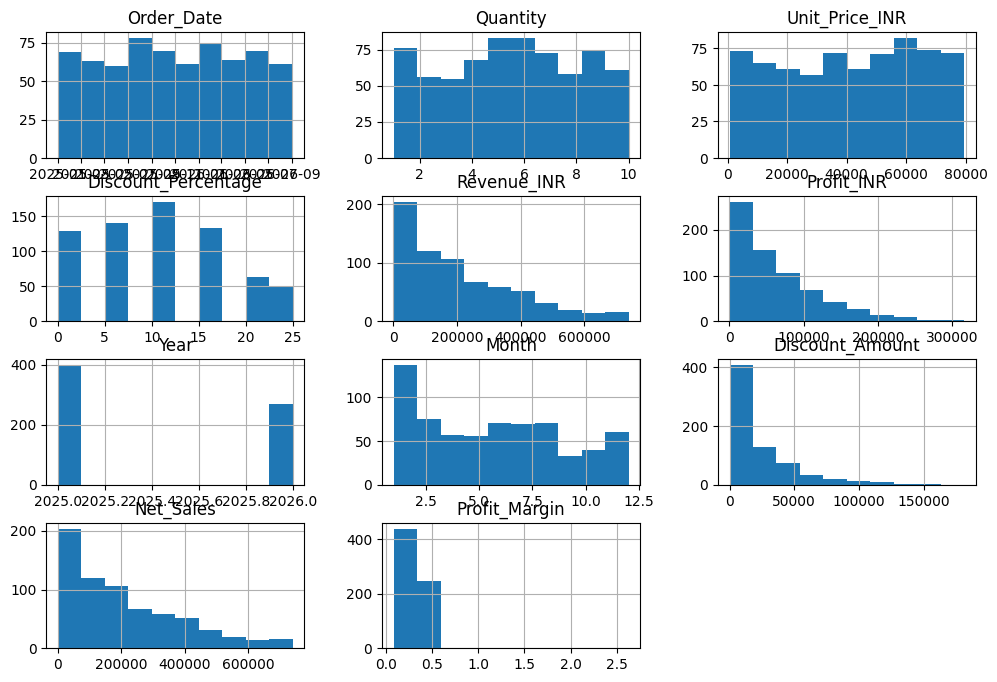

In [ ]:
# Summary statistics
print(df.describe(include='all'))

# Distribution of numeric columns
df.hist(figsize=(12,8))

# Frequency counts for categorical columns
for col in df.select_dtypes(include=['object','category']).columns:
    print(f"\nColumn: {col}")
    print(df[col].value_counts().head())


***2. Bivariate Analysis***

Explore relationships between two variables.

In [ ]:
# Check column names first to avoid errors
print(df.columns)

# Plot only if both columns exist
if {'Revenue','Cost'}.issubset(df.columns):
    sns.scatterplot(x='Cost', y='Revenue', data=df, hue='Region', palette='coolwarm')
    plt.title("Cost vs Revenue by Region")
    plt.xlabel("Cost")
    plt.ylabel("Revenue")
    plt.legend(title="Region")
    plt.show()


Index(['Order_ID', 'Order_Date', 'Customer_ID', 'Customer_Name',
       'Customer_Segment', 'Product_ID', 'Product_Name', 'Product_Category',
       'Region', 'State', 'Sales_Channel', 'Quantity', 'Unit_Price_INR',
       'Discount_Percentage', 'Revenue_INR', 'Profit_INR', 'Year', 'Month',
       'Discount_Amount', 'Net_Sales', 'Profit_Margin', 'Order_Size',
       'Customer_Value'],
      dtype='object')


In [ ]:
if {'Region','Revenue'}.issubset(df.columns):
    sns.boxplot(x='Region', y='Revenue', data=df, palette='Set2')
    plt.title("Revenue Spread by Region")
    plt.show()


In [ ]:
if {'PaymentMethod','Fare'}.issubset(df.columns):
    sns.violinplot(x='PaymentMethod', y='Fare', data=df, palette='muted')
    plt.title("Fare Distribution by Payment Method")
    plt.show()


In [ ]:
# Scatter plot: Revenue vs Cost
if {'Revenue','Cost'}.issubset(df.columns):
    sns.scatterplot(x='Cost', y='Revenue', data=df, hue='Region', palette='coolwarm')
    plt.title("Cost vs Revenue by Region")
    plt.show()

# Boxplot: Revenue by Region
if {'Region','Revenue'}.issubset(df.columns):
    sns.boxplot(x='Region', y='Revenue', data=df, palette='Set2')
    plt.title("Revenue Spread by Region")
    plt.show()

# Correlation between two numeric columns
if {'Revenue','Cost'}.issubset(df.columns):
    print(df[['Revenue','Cost']].corr())


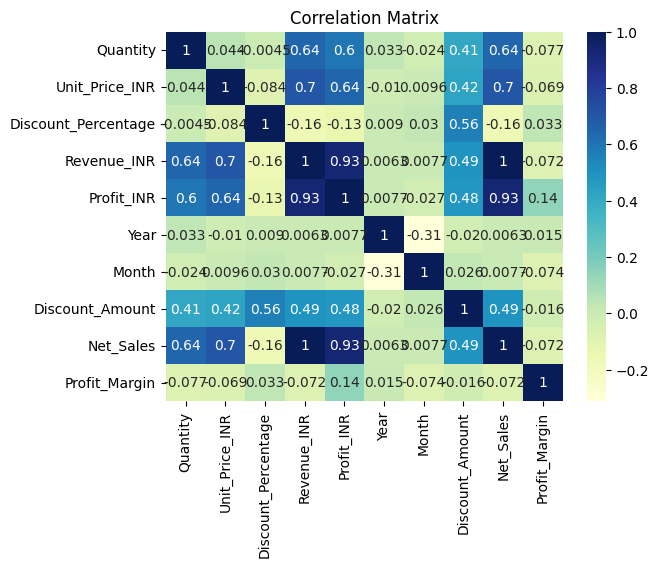

In [ ]:
# Select only numeric columns
numeric_cols = df.select_dtypes(include=['float64','int64']).columns
corr = df[numeric_cols].corr()

sns.heatmap(corr, annot=True, cmap="YlGnBu")
plt.title("Correlation Matrix")
plt.show()


***3. Multivariate Analysis***

Look at interactions among multiple variables.

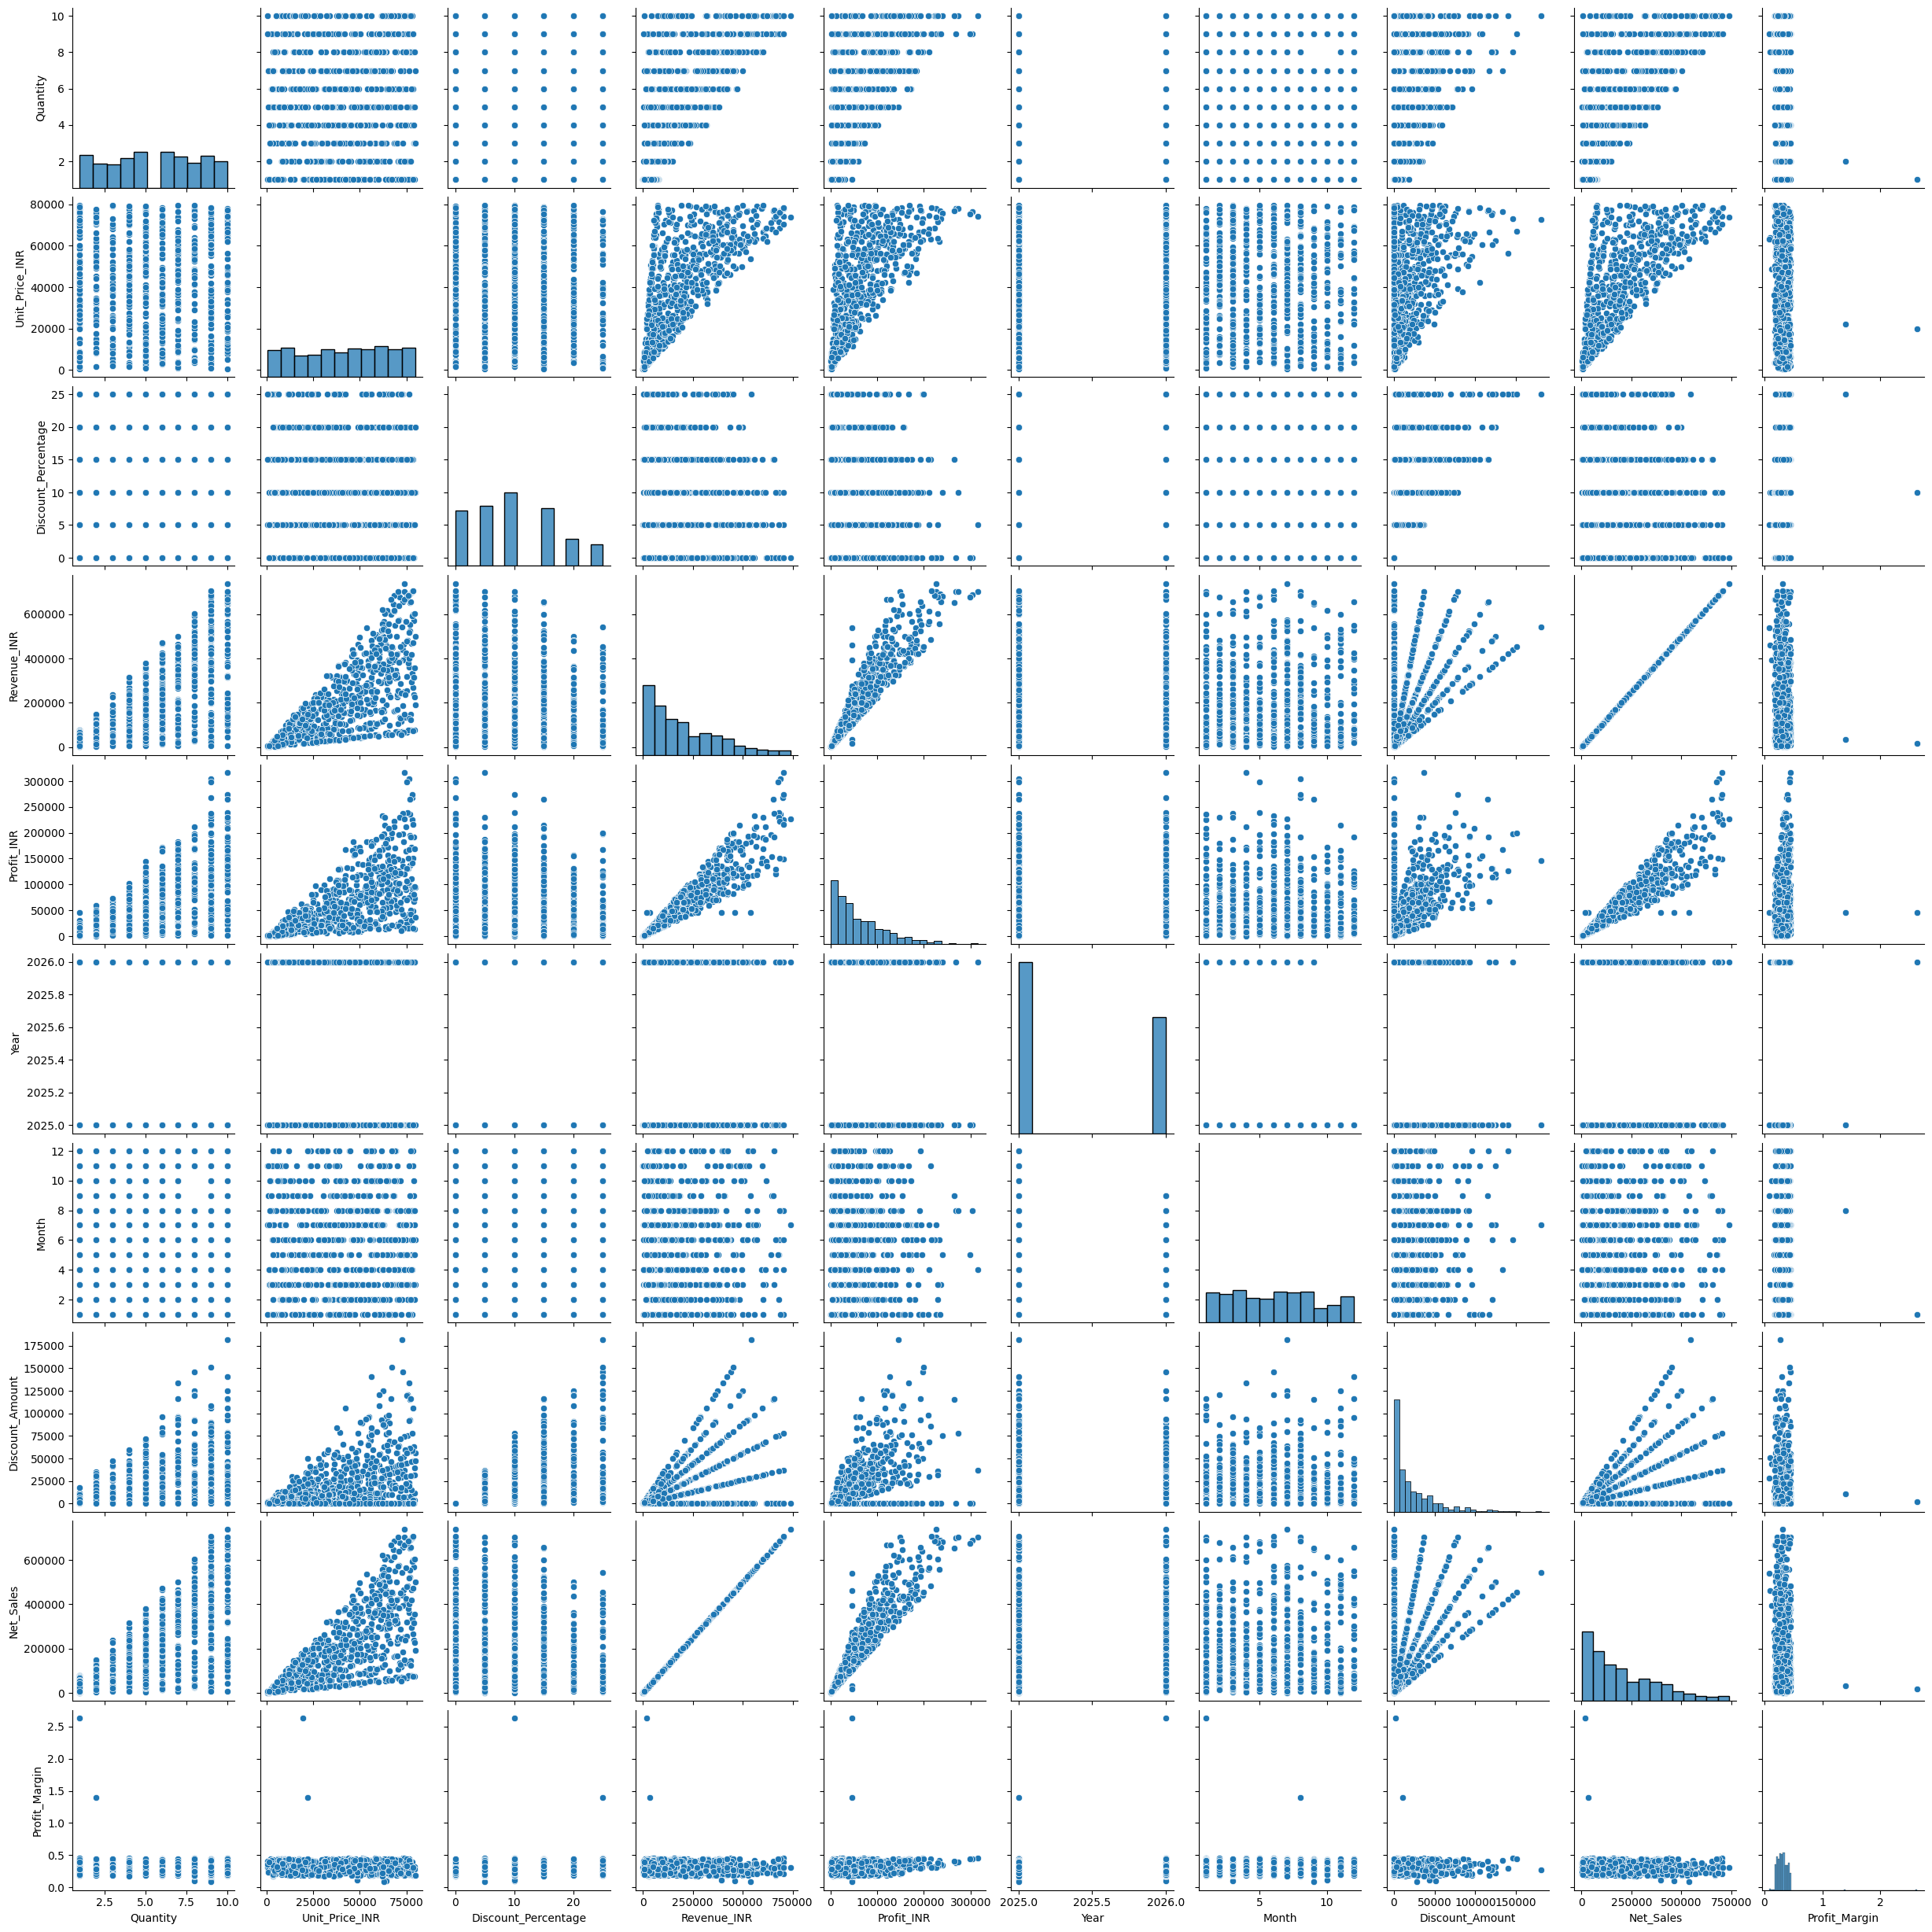

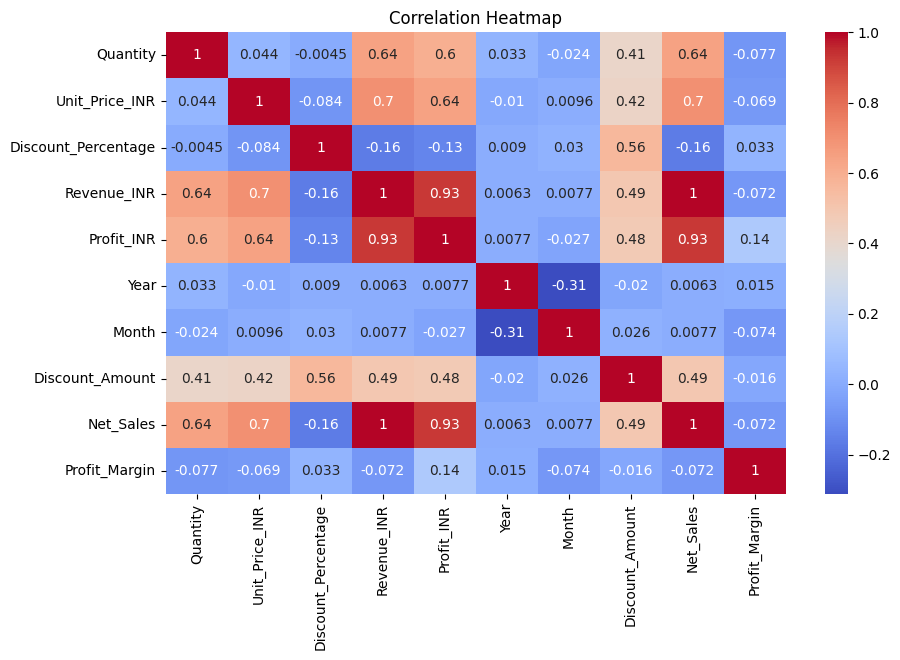

In [ ]:
# Pairplot for multiple numeric features
sns.pairplot(df.select_dtypes(include=['float64','int64']))

# Heatmap of correlations
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


***4. GroupBy Analysis***

Aggregate data by categories.

In [ ]:
if {'Region','Revenue'}.issubset(df.columns):
    sales_by_region = df.groupby('Region')['Revenue'].mean().reset_index()
    sns.barplot(x='Region', y='Revenue', data=sales_by_region, palette='viridis')
    plt.title("Average Revenue by Region")
    plt.show()


In [ ]:
if {'Region','Revenue'}.issubset(df.columns):
    sales_by_region = df.groupby('Region')['Revenue'].sum().reset_index()
    print(sales_by_region)

if {'Year','Profit'}.issubset(df.columns):
    avg_profit_by_year = df.groupby('Year')['Profit'].mean().reset_index()
    print(avg_profit_by_year)


***5.Correlation Analysis***

Identify linear relationships between numeric features.




                     Quantity  Unit_Price_INR  Discount_Percentage  \
Quantity             1.000000        0.044441            -0.004480   
Unit_Price_INR       0.044441        1.000000            -0.083827   
Discount_Percentage -0.004480       -0.083827             1.000000   
Revenue_INR          0.642337        0.700928            -0.164605   
Profit_INR           0.597289        0.643874            -0.134042   
Year                 0.032921       -0.010159             0.009022   
Month               -0.023512        0.009621             0.030221   
Discount_Amount      0.411681        0.422681             0.562788   
Net_Sales            0.642337        0.700928            -0.164605   
Profit_Margin       -0.077498       -0.068597             0.032616   

                     Revenue_INR  Profit_INR      Year     Month  \
Quantity                0.642337    0.597289  0.032921 -0.023512   
Unit_Price_INR          0.700928    0.643874 -0.010159  0.009621   
Discount_Percentage    -0

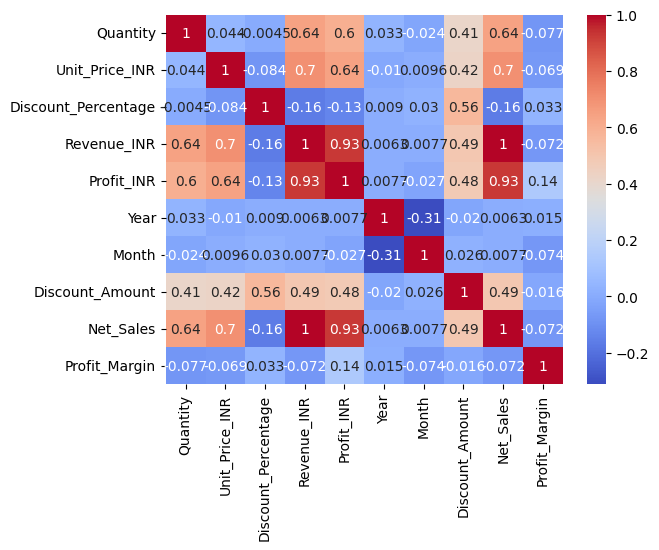

In [ ]:
# Correlation matrix
corr_matrix = df.corr(numeric_only=True)
print(corr_matrix)

# Visualize correlations
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.show()


#**4. Visualizations**

  *For Exploratory Data Analysis (EDA), visualizations are the most powerful way to uncover insights*
  

***Seaborn Visualization***

#*1. Bar Plot*

Compare categorical values.

/tmp/ipykernel_3028/734270022.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Region', y='Revenue_INR', data=df, palette='viridis')


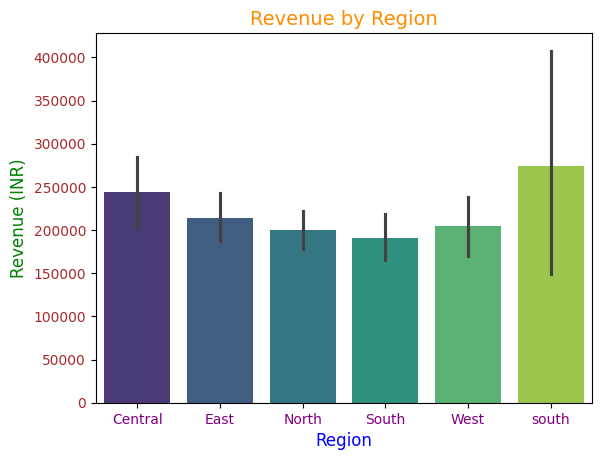

In [ ]:
sns.barplot(x='Region', y='Revenue_INR', data=df, palette='viridis')
plt.title("Revenue by Region", color='darkorange', fontsize=14)
plt.xlabel("Region", color='blue', fontsize=12)
plt.ylabel("Revenue (INR)", color='green', fontsize=12)
plt.xticks(color='purple')
plt.yticks(color='brown')
plt.show()


#*2. Line Chart*

Result: A line chart with months on the x-axis and revenue on the y-axis. Each year has a separate line, showing seasonal peaks and dips.

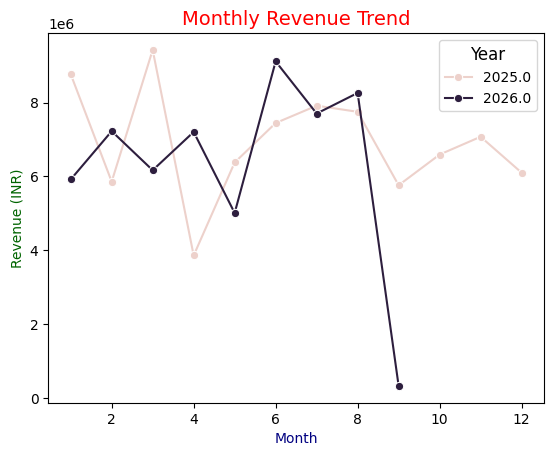

In [ ]:
monthly_sales = df.groupby(['Year','Month'])['Revenue_INR'].sum().reset_index()
sns.lineplot(x='Month', y='Revenue_INR', hue='Year', data=monthly_sales, marker='o')
plt.title("Monthly Revenue Trend", color='red', fontsize=14)
plt.xlabel("Month", color='navy')
plt.ylabel("Revenue (INR)", color='darkgreen')
plt.legend(title="Year", labelcolor='black', title_fontsize=12, fontsize=10)
plt.show()


#*3. Pie Chart*

Result: A pie chart with slices for each region, labeled with percentages. Great for showing proportional contribution.

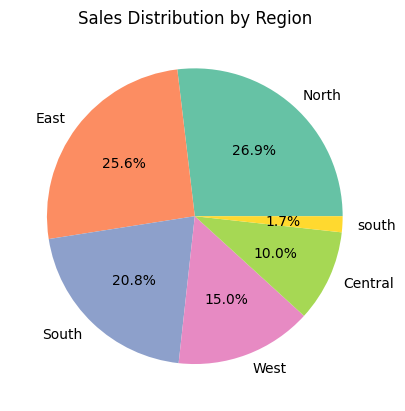

In [ ]:
df['Region'].value_counts().plot.pie(
    autopct='%1.1f%%',
    colors=sns.color_palette("Set2")
)
plt.title("Sales Distribution by Region")
plt.ylabel("")
plt.show()


#*4. Histogram*

Result: A histogram with a smooth KDE curve overlay, showing how revenue values are distributed (e.g., most orders cluster around mid-range values).

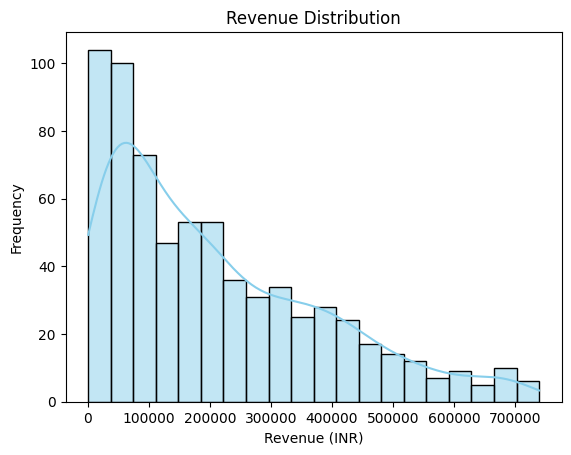

In [ ]:
sns.histplot(df['Revenue_INR'], bins=20, kde=True, color='skyblue')
plt.title("Revenue Distribution")
plt.xlabel("Revenue (INR)")
plt.ylabel("Frequency")
plt.show()


#*5. Box Plot*

Result: Each product category has a box plot showing median profit, spread, and outliers. Electronics may show wider variance compared to office supplies.

/tmp/ipykernel_3028/3381618450.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Product_Category', y='Profit_INR', data=df, palette='Set2')


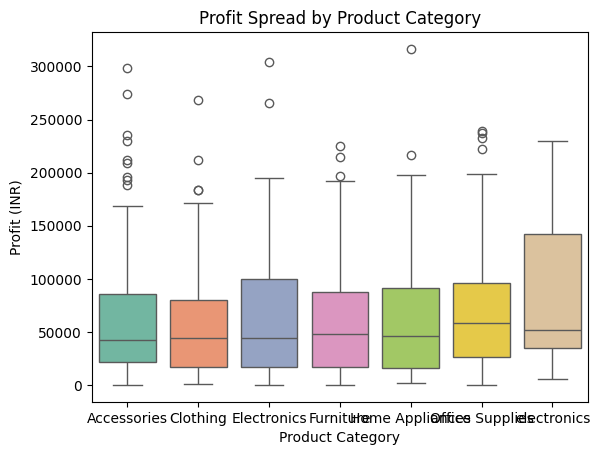

In [ ]:
sns.boxplot(x='Product_Category', y='Profit_INR', data=df, palette='Set2')
plt.title("Profit Spread by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Profit (INR)")
plt.show()


#*6. Scatter Plot*

Result: A scatter plot where each point represents an order. You’ll see how higher discounts often reduce profit, with color-coded regions.

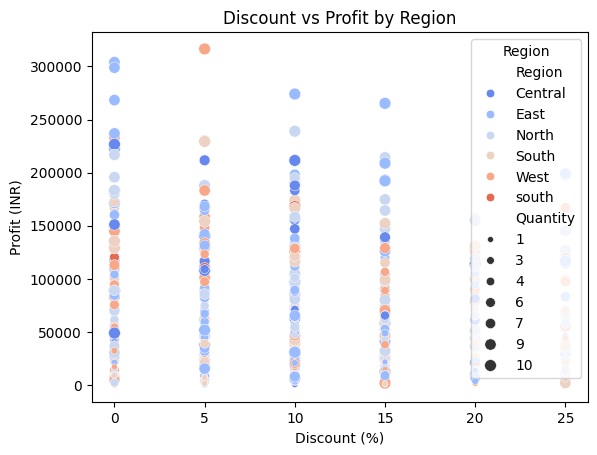

In [ ]:
sns.scatterplot(
    x='Discount_Percentage', y='Profit_INR',
    hue='Region', size='Quantity',
    data=df, palette='coolwarm'
)
plt.title("Discount vs Profit by Region")
plt.xlabel("Discount (%)")
plt.ylabel("Profit (INR)")
plt.legend(title="Region")
plt.show()


#*7. Heatmap*

Result: A matrix showing correlations between numeric features (Revenue, Profit, Discount, Quantity). Strong positive/negative relationships are highlighted in blue/green shades.

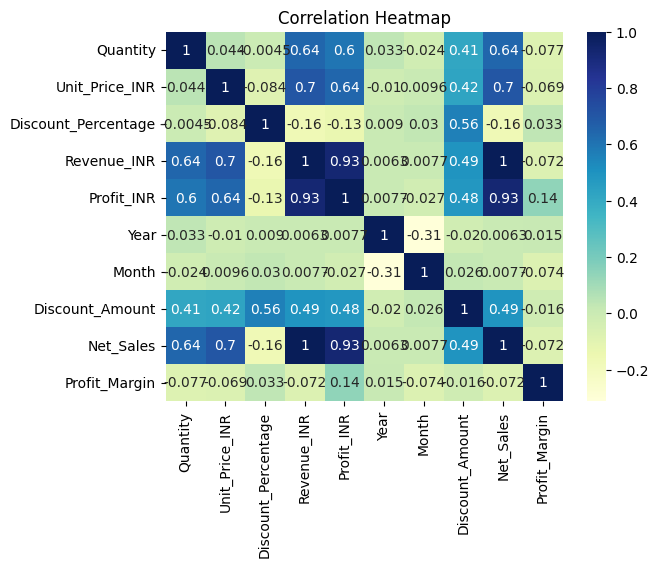

In [ ]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="YlGnBu")
plt.title("Correlation Heatmap")
plt.show()


#*8. Subplots*

Result: Side-by-side comparison of revenue distribution (histogram) and spread (box plot). This layout makes it easy to interpret both at once.

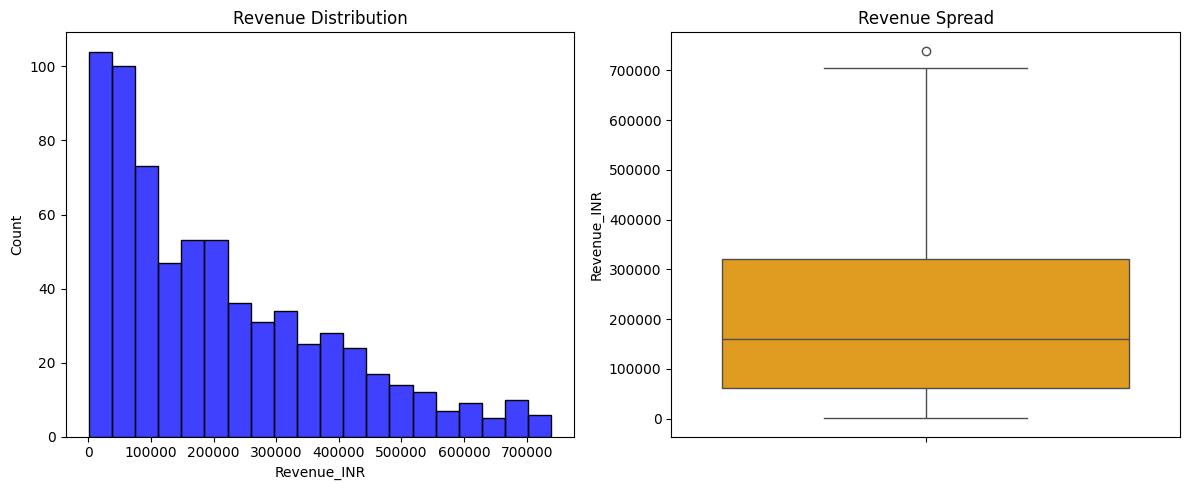

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

sns.histplot(df['Revenue_INR'], bins=20, ax=axes[0], color='blue')
axes[0].set_title("Revenue Distribution")

sns.boxplot(y=df['Revenue_INR'], ax=axes[1], color='orange')
axes[1].set_title("Revenue Spread")

plt.tight_layout()
plt.show()


#*9.Swarm Plot*

A swarm plot shows individual data points, making it easy to see clusters and outliers.

/tmp/ipykernel_3028/1667814462.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(x='Discount_Percentage', y='Profit_INR', data=df, palette='coolwarm')
/usr/local/lib/python3.13/dist-packages/seaborn/categorical.py:3399: UserWarning: 5.4% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.13/dist-packages/seaborn/categorical.py:3399: UserWarning: 12.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.13/dist-packages/seaborn/categorical.py:3399: UserWarning: 12.9% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.13/dist-p

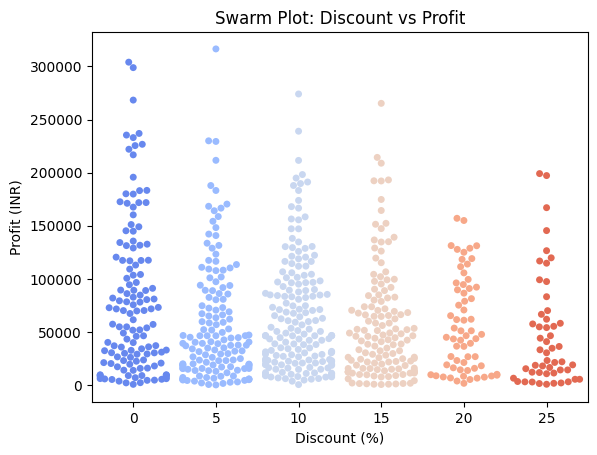

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.swarmplot(x='Discount_Percentage', y='Profit_INR', data=df, palette='coolwarm')
plt.title("Swarm Plot: Discount vs Profit")
plt.xlabel("Discount (%)")
plt.ylabel("Profit (INR)")
plt.show()


#*10: Violin Plot*

A violin plot combines box plot and KDE, showing both spread and density of profit across segments.

/tmp/ipykernel_3028/3200353644.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Customer_Segment', y='Profit_INR', data=df, palette='muted')


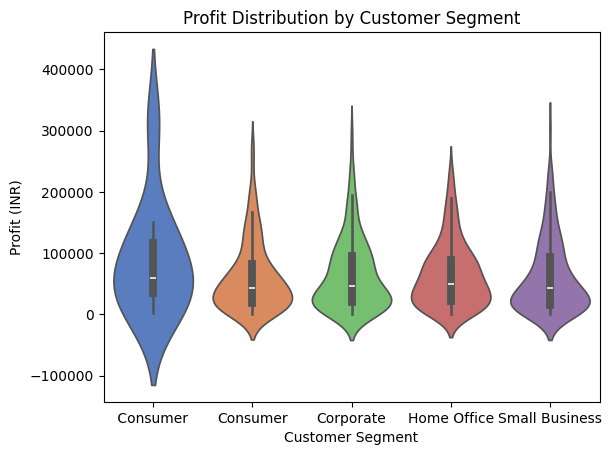

In [ ]:
sns.violinplot(x='Customer_Segment', y='Profit_INR', data=df, palette='muted')
plt.title("Profit Distribution by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Profit (INR)")
plt.show()


#**5. Insight Generation and Report**



#**Logic & Method**

This project followed a structured sales analytics workflow to transform raw transactional data into meaningful business insights.

Missing values in Profit_INR, State, Sales_Channel, and Customer_Name were handled using appropriate imputation techniques.
Duplicate records were removed to ensure accurate reporting.
Data types were corrected to support reliable calculations and time-series analysis.
New analytical features such as Profit Margin, Discount Amount, Net Sales, Order Size, Customer Value, Year, and Month were created to enhance business analysis.
Exploratory Data Analysis (EDA) was performed using descriptive statistics, aggregation techniques, and visualizations to understand customer behavior, product performance, regional sales patterns, and profitability drivers.
Key Findings from the Analysis
#1. Revenue Distribution

The dataset contains 688 cleaned sales transactions with total revenue distributed across multiple product categories, customer segments, and geographical regions.

Revenue values show a wide distribution ranging from small transactions to high-value orders.
The average transaction revenue is substantially higher than the minimum revenue, indicating variation in order sizes.
Histogram analysis suggests that medium-value transactions occur more frequently, while very large orders are comparatively less common.

Business Insight: Revenue generation depends on both high-order-value customers and consistent medium-sized transactions.

#2. Profitability Analysis

Profit values vary considerably across transactions.

The average profit is lower than revenue, indicating that profitability is influenced by discounts, quantity sold, and pricing strategies.
Profit margin calculations reveal differences in profitability between individual orders.
Box plots demonstrate the presence of high-profit and low-profit transactions, suggesting variation in sales effectiveness across products and customers.

Business Insight: Revenue growth alone does not guarantee profit growth. Monitoring profit margin is essential when evaluating business performance.

#3. Impact of Discounts on Profit

The scatter plot between Discount Percentage and Profit_INR highlights the relationship between discounting and profitability.

Orders with lower discounts generally maintain stronger profitability.
Higher discount levels tend to reduce overall profit generated per transaction.
A noticeable spread in profit values across discount ranges indicates that other factors such as product category and order quantity also affect profitability.

Business Insight: Excessive discounting may boost sales volume but can reduce profit margins. Discount strategies should be optimized carefully.

#4. Regional Sales Performance

Regional aggregations and visualizations indicate differences in sales activity across regions.

Revenue is distributed across all business regions rather than concentrated in a single market.
Certain regions contribute a larger share of transactions and revenue.
Regional performance comparisons reveal opportunities to investigate why some locations outperform others.

Business Insight: High-performing regions can be used as benchmark markets, while lower-performing regions may require targeted sales and marketing initiatives.

#5. Product Category Performance

Product category analysis demonstrates differences in both sales volume and profitability.

Some categories generate higher revenue due to stronger demand.
Profit distribution varies significantly across categories.
Categories with higher revenue do not always generate the highest profits.

Business Insight: Product decisions should be based on both revenue contribution and profitability rather than revenue alone.

#6. Customer Segment Analysis

Customer segmentation reveals different purchasing behaviors.

Customer groups contribute differently to total revenue and profit.
Some segments place higher-value orders, while others generate revenue through frequent purchases.
Profitability patterns vary across customer segments.

Business Insight: Marketing campaigns should be customized for each customer segment to maximize retention and profitability.

#7. Customer Value Segmentation

Customers were segmented into four revenue-based groups:

Low Value
Medium Value
High Value
Top Value

This segmentation helps identify customers who contribute the most revenue.

Business Insight: High-value and top-value customers should receive personalized engagement, loyalty benefits, and retention initiatives.

#8. Order Size Analysis

Orders were classified into:

Small
Medium
Large
Bulk

The analysis shows variability in revenue and profit across different order sizes.

Larger orders generally contribute higher revenue.
Profitability may vary depending on discounts applied to bulk purchases.

Business Insight: Encouraging larger order sizes without excessive discounting can improve revenue and profitability simultaneously.

#**Correlation Analysis**

The correlation heatmap highlights relationships among key numerical variables.

Revenue shows a positive relationship with quantity sold and unit price.
Profit generally increases as revenue increases.
Discount percentage has a relatively weaker and potentially negative association with profitability compared to revenue.

Business Insight: Revenue growth is primarily driven by pricing and sales volume rather than discounting strategies.

#**Data Quality Observations**

Several data quality issues were identified and resolved during preprocessing:

Missing values were found in customer, geographical, channel, and profit fields.
Duplicate records existed within the original dataset.
Date fields required conversion to datetime format.
Categorical variables required standardization for consistent analysis.

Business Insight: Data quality management significantly improves the reliability of analytical findings and business decision-making.

#**Business Recommendations**
Revenue Growth

Focus on product categories and customer segments generating the highest revenue.
Expand successful sales strategies into underperforming regions.

Profitability Improvement
Review discount policies regularly.
Monitor profit margins alongside revenue metrics.

Customer Retention
Develop loyalty programs for high-value customers.
Offer personalized promotions based on purchasing behavior.

Product Strategy
Prioritize products with strong revenue and profit performance.
Reassess products that generate sales but deliver low profitability.

Regional Expansion
Investigate factors contributing to strong regional performance.
Replicate successful regional practices in developing markets.

#**Final Conclusion**

The Sales Analytics Dashboard successfully transformed raw transaction data into actionable business intelligence through data cleaning, feature engineering, exploratory analysis, aggregation, and visualization. The analysis demonstrates that revenue, profitability, customer behavior, discount strategies, and regional performance are interconnected business drivers. By leveraging these insights, organizations can make data-driven decisions that improve revenue growth, operational efficiency, and long-term profitability.